# Delays are all you need 

This is a notebook to reproduce the [Delays are all you need](https://verzep.github.io/Takens/) page. Besides, I will also repeat these things on Mackey-Glass data to see what attractor it can show.

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## data generation

Totally 12000 time steps, range from 0 to 12000

### Lorenz system

stored in ```y_l```, an ```np.array``` with dimension ```(3,12000)```

time stored in ```t```

In [11]:
# Define the Lorenz system of differential equations
def lorenz(t, y, sigma, rho, beta):
    dydt = [sigma * (y[1] - y[0]),
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return dydt

# Set the parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

# Set the initial conditions
initial_conditions = [1.0, 0.0, 20.0]

# Set the time span for integration
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 12000)

# Solve the system of differential equations
sol = solve_ivp(lorenz, 
                t_span, 
                initial_conditions, 
                args=(sigma, rho, beta), 
                t_eval=t_eval
            )

# Extract the solution
y_l = sol.y
t = sol.t

In [31]:
fig = go.Figure(data=[go.Scatter3d(
    x=y_l[0], y=y_l[1], z=y_l[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz Attractor')
fig.show()

### MG data

stored in ```y_mg```, an ```np.array``` with dimension ```12000```

In [15]:
def MG_generate_interp(gamma=0.1, beta=0.2, tau=60, theta=1, n=10, x0=1, N=2000000, delta=0.01):
    def MG_eq(x, x_pre):
        return x_pre * beta * ((theta**n)/(theta**n + x_pre**n)) - gamma * x

    def MG_rk4(x, x_pre, x_pre_f):
        interplot = (x_pre + x_pre_f)/2
        k1 = MG_eq(x, x_pre)
        k2 = MG_eq(x + delta * k1 / 2, interplot)
        k3 = MG_eq(x + delta * k2 / 2, interplot)
        k4 = MG_eq(x + delta * k3, x_pre_f)
        return x + delta * (k1 + 2*k2 + 2*k3 + k4)/6

    past_len = int(np.floor(tau / delta))
    x_past = np.zeros(past_len + N + 1) + 0.1
    X = np.zeros(N + 1)
    T = np.zeros(N + 1)

    X_pert_p = np.zeros(N + 1)     # perturbed version
    X_pert_n = np.zeros(N + 1)  

    time = 0
    x = x0
    x_pert_p = x0
    x_pert_n = x0

    ptb_idx = int(np.floor(N * 0.8))  # perturbation index

    for i in range(N + 1):
        # normal series
        x_pre = x_past[i]
        x_pre_f = x_past[i + 1]
        x_delta = MG_rk4(x, x_pre, x_pre_f)
        x_past[i + past_len] = x_delta
        X[i] = x
        T[i] = time
        x = x_delta

    # use a *copy* of x_past for perturbed version
    x_past_pert_p = x_past.copy()

    for i in range(N + 1):
        x_pre = x_past_pert_p[i]
        x_pre_f = x_past_pert_p[i + 1]
        x_delta = MG_rk4(x_pert_p, x_pre, x_pre_f)

        if i == ptb_idx:
            x_delta += 0.1  # apply small perturbation at time index N*0.8

        x_past_pert_p[i + past_len] = x_delta
        X_pert_p[i] = x_pert_p
        x_pert_p = x_delta

    

    x_past_pert_n = x_past.copy()

    for i in range(N + 1):
        x_pre = x_past_pert_n[i]
        x_pre_f = x_past_pert_n[i + 1]
        x_delta = MG_rk4(x_pert_n, x_pre, x_pre_f)

        if i == ptb_idx:
            x_delta  = x_delta - 0.1  # apply small perturbation at time index N*0.8

        x_past_pert_n[i + past_len] = x_delta
        X_pert_n[i] = x_pert_n
        x_pert_n = x_delta

    interval = int(np.floor(1 / delta))
    return T[::interval], X[::interval], X_pert_p[::interval], X_pert_n[::interval]


_,y_mg,y_mg_pert_p, y_mg_pert_n = MG_generate_interp(N = 12000000,tau = 30,delta = 0.001)

y_mg = np.array(y_mg)[1:]
y_mg_pert_p = np.array(y_mg_pert_p)[1:]
y_mg_pert_n = np.array(y_mg_pert_n)[1:]

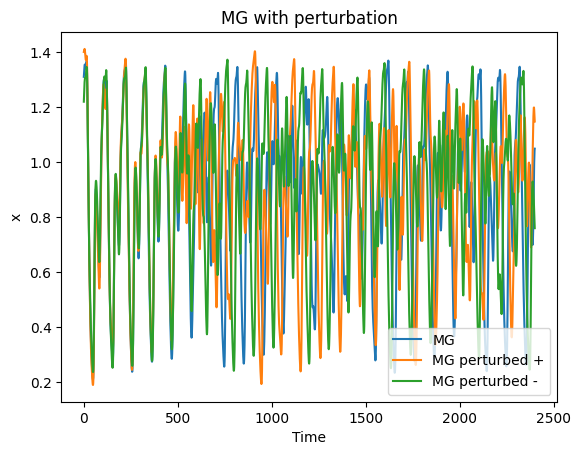

In [16]:
plt.plot(y_mg[9600:], label='MG')
plt.plot(y_mg_pert_p[9600:], label='MG perturbed +')
plt.plot(y_mg_pert_n[9600:], label='MG perturbed -')
plt.title('MG with perturbation')
plt.xlabel('Time')  
plt.ylabel('x')
plt.legend()
plt.show()

## delay embeddings

setting delay embeddings with 20 delay steps and each delay with 1 steps.

delay embeddins of x from lorenz system stored in ```de_l```, an ```np.array``` with dimension ```(11981,20)```

delay embeddins of x from l MGdata stored in ```de_mg```, an ```np.array``` with dimension ```(11981,20)```

In [17]:
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    return data[indices]

In [18]:
de_l = delay_embedding(y_l[0], 20, 1)
de_l = np.array(de_l)

In [19]:
de_mg = delay_embedding(y_mg, 20, 1)
de_mg = np.array(de_mg)

In [21]:
temp = y_mg[9600:]
temp_pert_p = y_mg_pert_p[9600:]
temp_pert_n = y_mg_pert_n[9600:]
de_mg_temp = delay_embedding(temp, 3, 1)
de_mg_temp_pert_p = delay_embedding(temp_pert_p, 3, 1)
de_mg_temp_pert_n = delay_embedding(temp_pert_n, 3, 1)

In [25]:
for temp_stp in [100, 300, 400, 500, 700, 1000, 1500, 2000]:
    fig = go.Figure(data=[
        go.Scatter3d(
            x=de_mg[5000:,0], 
            y=de_mg[5000:,1], 
            z=de_mg[5000:,2],
            mode='lines',
            line=dict(width=2, color='rgba(128,128,128,0.7)')
        ),
        go.Scatter3d(
            x=de_mg_temp[temp_stp-100:temp_stp+100, 0],  # Change this slice as needed
            y=de_mg_temp[temp_stp-100:temp_stp+100, 1],
            z=de_mg_temp[temp_stp-100:temp_stp+100, 2],
            # mode='lines',
            # line=dict(width=2, color='rgba(0,0,255,0.5)')
            mode='markers',
            marker=dict(size=1, color='rgba(255,0,0,0.7)', symbol='circle')
        ),
        go.Scatter3d(
            x=de_mg_temp_pert_p[temp_stp-100:temp_stp+100, 0],  # Change this slice as needed
            y=de_mg_temp_pert_p[temp_stp-100:temp_stp+100, 1],
            z=de_mg_temp_pert_p[temp_stp-100:temp_stp+100, 2],
            # mode='lines',
            # line=dict(width=2, color='rgba(255,0,0,0.5)')
            mode='markers',
            marker=dict(size=1, color='rgba(0,0,255,0.7)', symbol='circle')
        ),
        go.Scatter3d(
            x=de_mg_temp_pert_n[temp_stp-100:temp_stp+100, 0],  # Change this slice as needed
            y=de_mg_temp_pert_n[temp_stp-100:temp_stp+100, 1],
            z=de_mg_temp_pert_n[temp_stp-100:temp_stp+100, 2],
            # mode='lines',
            # line=dict(width=2, color='rgba(255,0,0,0.5)')
            mode='markers',
            marker=dict(size=1, color='rgba(0,255,0,0.7)', symbol='circle')
        )
    
    ])
    fig.update_layout(title=f'delay embedding of MG time series at {temp_stp-100}')
    fig.show()


## SVD of embedded data

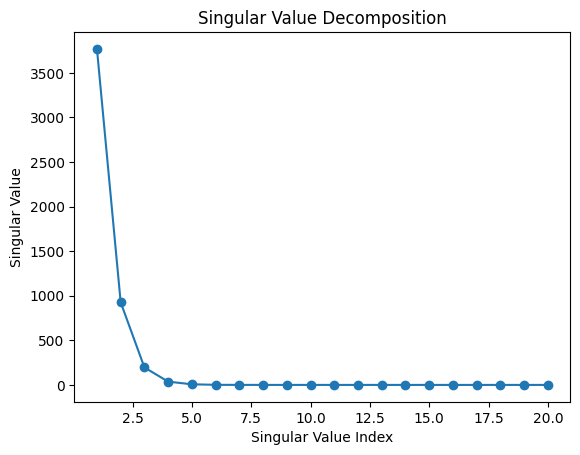

In [26]:
U, S, vh = np.linalg.svd(de_l.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [27]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz attractor revealed from one dimensional time series')
fig.show()


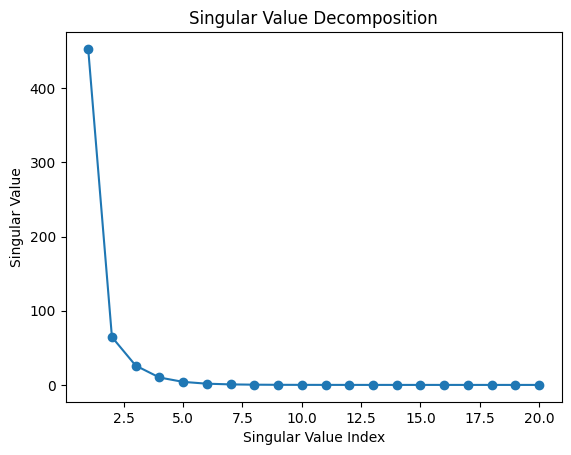

In [28]:
U, S, vh = np.linalg.svd(de_mg.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [29]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='attractor revealed from Mackey Glass time series')
fig.show()


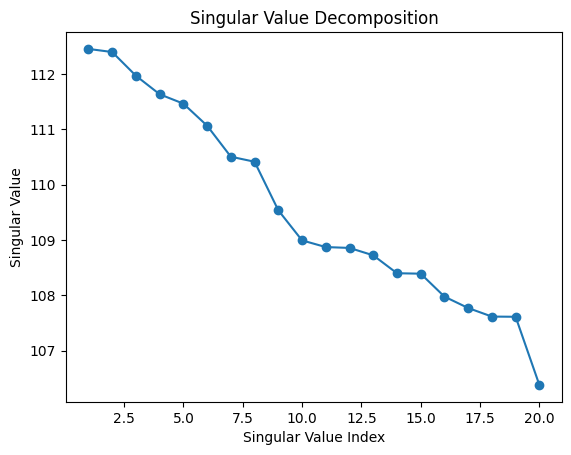

In [ ]:
wn = np.random.normal(0, 1, 12000)

de_wn = delay_embedding(wn, 20, 1)

U, S, vh = np.linalg.svd(de_wn.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [30]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='attractor revealed from white noise time series')
fig.show()